### Inläsning och förståelse av data (Kodblock 1)

Jag började arbetet inleddes med att läsa in MNIST-datasetet via fetch_openml. Datasetet består av 70 000 observationer där varje bild representeras av 784 pixlar (28x28). I detta steg kontrollerade jag datans dimensioner och konverterade målvariabeln till numeriskt format. Jag ville säkerställa att datan var korrekt formaterad innan jag gick vidare

### Uppdelning av data (Kodblock 2)

Därefter delade jag upp datasetet i tränings-, validerings- och testmängd. Jag valde att använda tre delmängder för att kunna: träna modeller på träningsdata, välja modell och optimera parametrar på valideringsdata, göra en slutlig, opartisk utvärdering på testdata. Jag använde stratifiering för att säkerställa att fördelningen av siffrorna 0–9 blev jämn i alla delmängder. Detta för att minska risken att modellen tränas på en skev klassfördelning.

### Skalning av data (Kodblock 3)

Eftersom vissa modeller, särskilt Logistic Regression, är känsliga för skalan på indata standardiserade jag features med StandardScaler. Jag anpassade skalaren (fit) enbart på träningsdata och applicerade sedan transformationen (transform) på validerings- och testdata.

### Träning av kandidater (Kodblock 4)

I nästa steg tränade jag fyra olika modeller:

- Logistic Regression
- Random Forest
- Extra Trees
- Voting Classifier

Samtliga modeller tränades enbart på träningsdatan. I detta kodblock genomfördes ingen utvärdering, utan syftet var att skapa tränade kandidater inför jämförelsen. Genom att tydligt separera träning och utvärdering blev processen mer strukturerad och lättare att följa för mig.

### Modellutvärdering på valideringsdata (Kodblock 5)

Efter träningen utvärderade jag modellerna på valideringsmängden. Jag använde flera mått:

- Accuracy
- Precision
- Recall
- F1-score

Resultatet visade att Extra Trees presterade bäst, följt av Random Forest, medan Logistic Regression presterade lägre. Detta indikerade att problemet är icke-linjärt och att trädmodeller är bättre lämpade för denna typ av bilddata. I den inledande modelljämförelsen använde jag en traditionell train/validation-split för att effektivt kunna jämföra flera modeller. När den mest lovande modellen identifierats valde jag att gå vidare med en mer fördjupad optimering.

### Hyperparameteroptimering (Kodblock 6)

När Extra Trees visade sig vara den bäst presterande modellen valde jag att optimera den vidare med hjälp av GridSearchCV.

Jag testade olika kombinationer av:

- antal träd
- max features
- max djup
- minsta antal observationer per löv

Optimeringen genomfördes med 3-fold cross validation och utvärderingsmåttet f1_macro. Genom att först använda en enkel train/validation-split och därefter cross validation för den utvalda modellen försökte jag uppnå en god balans mellan beräkningseffektivitet och metodologisk noggrannhet. Vid deployment användes en praktiskt anpassad version av modellen baserad på optimeringsresultatet, med något begränsad komplexitet för att minska filstorleken.

### Utvärdering av optimerad modell på valideringsdata (Kodblock 7)

Efter hyperparameteroptimeringen valde jag den modell som presterade bäst i grid search. Den testades sedan på valideringsdatan för att se hur den fungerade på ny data. För att analysera resultatet använde jag en classification report och en confusion matrix. De visade både modellens totala noggrannhet och vilka siffror som ibland blandades ihop. Resultatet visade en liten men tydlig förbättring jämfört med baseline-modellen.

### Slutlig testutvärdering (Kodblock 8)

När den bästa modellen hade identifierats genom optimeringen tränades den om på hela tränings- och valideringsmängden tillsammans för att utnyttja så mycket data som möjligt. Därefter genomfördes en slutlig utvärdering på den separata testmängden för att uppskatta modellens generaliseringsförmåga på helt osedd data. Resultatet visade att modellen uppnådde en fortsatt hög prestanda, med en accuracy på cirka 95 %, vilket var i linje med resultaten från tidigare valideringssteg.

I samband med att modellen skulle distribueras i en Streamlit-applikation behövde modellens komplexitet därefter begränsas genom att sätta ett maxdjup och ett minimikrav på antal observationer per löv. Detta gjordes för att minska modellens filstorlek och möjliggöra publicering via GitHub och Streamlit Cloud.

Jag är medveten om att testmängden i strikt metodik endast bör användas en gång i slutet av processen. I detta fall användes testdatan även för att verifiera att den förenklade modellen, som behövdes för deployment, inte försämrade prestandan. Eftersom justeringen gjordes av praktiska distributionsskäl och inte för ytterligare optimering av modellen bedömde jag att detta var rimligt inom ramen för projektet.

### Sparande av modell (Kodblock 9)

Den slutliga modellen och den anpassade scalern sparades med hjälp av joblib. I samband med detta kontrollerades modellens filstorlek för att säkerställa att den låg under GitHubs gräns för enskilda filer. Efter justering av modellens komplexitet uppgick filstorleken till cirka 67 MB, vilket möjliggjorde publicering och användning i en Streamlit-applikation.

### Avslutande reflektion

Genom att arbeta strukturerat och tydligt separera träning, validering och test har jag följt en korrekt maskininlärningsprocess, även om jag i slutändan blev tvungen att frångå den något. Arbetet har tydliggjort skillnaden mellan linjära och icke-linjära modeller samt vikten av att använda flera utvärderingsmått vid modelljämförelse. En viktig lärdom för mig har varit hur avgörande det är att arbeta metodiskt, särskilt i en notebook-miljö där körordningen påverkar resultatet. Jag har också fått en djupare förståelse för hur hyperparametrar påverkar modellens prestanda och hur en strukturerad optimeringsprocess kan förbättra resultatet på ett kontrollerat sätt.

## Import av lämpliga bibliotek

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score)


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier

from sklearn.model_selection import GridSearchCV
import joblib





Funktion

## Kodblock 1 - inläsning av data

(70000, 784)
(70000,)
Det sanna värdet för den printade bilden är 5


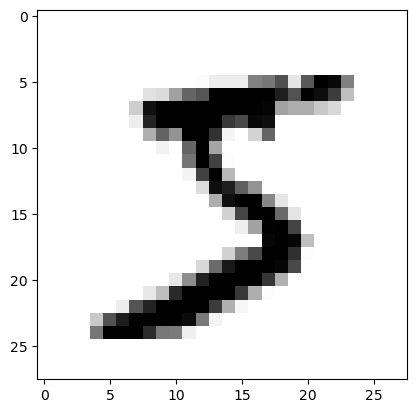

In [2]:
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
X = mnist["data"][:]
y = mnist["target"][:].astype(np.uint8)  # konverterar till int
print(X.shape)
print(y.shape)

some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
print("Det sanna värdet för den printade bilden är", y[0])



## Kodblock 2 - Train/validation/test-split (testdata 20%)

In [3]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, 
    test_size=14000, 
    random_state=42, 
    stratify=y
    )
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, 
    test_size=14000, 
    random_state=42,
    stratify=y_train_val
    )

In [4]:
print("Train-fördelning:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

print("\nValidation-fördelning:")
print(pd.Series(y_val).value_counts(normalize=True).sort_index())

print("\nTest-fördelning:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())


Train-fördelning:
0    0.098595
1    0.112548
2    0.099857
3    0.102024
4    0.097476
5    0.090190
6    0.098238
7    0.104167
8    0.097500
9    0.099405
Name: proportion, dtype: float64

Validation-fördelning:
0    0.098643
1    0.112500
2    0.099857
3    0.102000
4    0.097500
5    0.090143
6    0.098214
7    0.104214
8    0.097500
9    0.099429
Name: proportion, dtype: float64

Test-fördelning:
0    0.098643
1    0.112500
2    0.099857
3    0.102000
4    0.097500
5    0.090214
6    0.098214
7    0.104214
8    0.097500
9    0.099357
Name: proportion, dtype: float64


## Kodblock 3 - Skalning

In [5]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

## Kodblock 4 - Träning av modeller

In [6]:
logreg_clf = LogisticRegression(max_iter=1000)
random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
extra_trees_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)

named_estimators = [
    ("logreg_clf", logreg_clf),
    ("random_forest_clf", random_forest_clf),
    ("extra_trees_clf", extra_trees_clf)
]
voting_clf = VotingClassifier(named_estimators, voting='hard')

models = [logreg_clf, random_forest_clf, extra_trees_clf, voting_clf]
for model in models:
    model.fit(X_train, y_train)
    
print("Accuracy för resp modell")
model_names = ["Logistic Regression", "Random Forest", "Extra Trees", "Voting Classifier"]
for name, model in zip(model_names, models):
    score = model.score(X_val, y_val)
    print(f"{name:20s}:{score:.4f}")

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

Accuracy för resp modell
Logistic Regression :0.9099
Random Forest       :0.9666
Extra Trees         :0.9699
Voting Classifier   :0.9678


In [7]:
rows = []
for name, model in zip(model_names, models):
    y_pred = model.predict(X_val)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "F1_macro": f1_score(y_val, y_pred, average="macro", zero_division=0),
        "F1_weighted": f1_score(y_val, y_pred, average="weighted", zero_division=0),
        "Recall_macro": recall_score(y_val, y_pred, average="macro", zero_division=0),
        "Precision_macro": precision_score(y_val, y_pred, average="macro", zero_division=0),
    })

df = pd.DataFrame(rows).sort_values("F1_macro", ascending=False)
df


,Model,Accuracy,F1_macro,F1_weighted,Recall_macro,Precision_macro
2,Extra Trees,0.969857,0.969703,0.969843,0.969691,0.969759
3,Voting Classifier,0.967786,0.967583,0.967763,0.967565,0.967673
1,Random Forest,0.966643,0.966433,0.966612,0.966448,0.966492
0,Logistic Regression,0.909929,0.908891,0.909819,0.908911,0.909080


## Kodblock 5 - Utvärdering av modeller

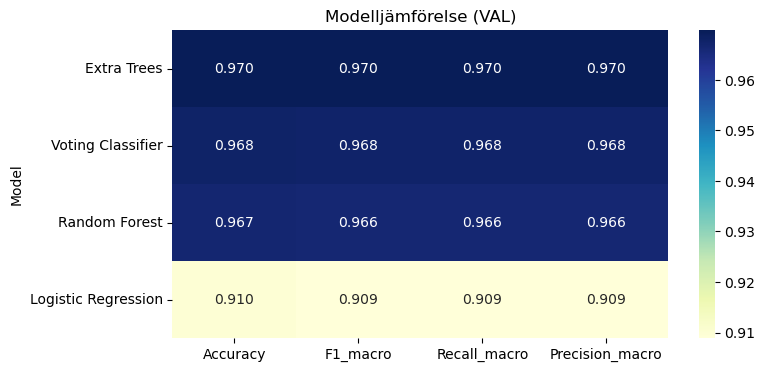

In [8]:
plt.figure(figsize=(8,4))
sns.heatmap(
    df.set_index("Model")[["Accuracy", "F1_macro", "Recall_macro", "Precision_macro"]],
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)

plt.title("Modelljämförelse (VAL)")
plt.show()


## Kodblock 6 - GridSearch på vinnarmodell

In [9]:
param_grid = {
    "n_estimators": [200, 500],
    "max_features": ["sqrt", "log2"],
    "max_depth": [None, 30],
    "min_samples_leaf": [1, 2]
}


In [ ]:
grid = GridSearchCV(
    ExtraTreesClassifier(random_state=42, n_jobs=-1),
    param_grid,
    scoring="f1_macro",  
    cv=3,
    n_jobs=-1,
    verbose=1
)


In [11]:
grid.fit(X_train_s, y_train)


Fitting 3 folds for each of 16 candidates, totalling 48 fits


,estimator,ExtraTreesCla...ndom_state=42)
,param_grid,"{'max_depth': [None, 30], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], 'n_estimators': [200, 500]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [12]:
print("Bästa parametrar:", grid.best_params_)
print("Bästa CV F1_macro:", grid.best_score_)


Bästa parametrar: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}
Bästa CV F1_macro: 0.9688255662437745


## Kodblock 7 – Utvärdering av optimerad modell på VAL

In [13]:
best_et = grid.best_estimator_


              precision    recall  f1-score   support

           0     0.9799    0.9862    0.9830      1381
           1     0.9823    0.9867    0.9845      1575
           2     0.9573    0.9771    0.9671      1398
           3     0.9692    0.9489    0.9590      1428
           4     0.9763    0.9648    0.9705      1365
           5     0.9744    0.9651    0.9697      1262
           6     0.9770    0.9869    0.9819      1375
           7     0.9738    0.9685    0.9711      1459
           8     0.9633    0.9604    0.9618      1365
           9     0.9501    0.9576    0.9538      1392

    accuracy                         0.9704     14000
   macro avg     0.9703    0.9702    0.9703     14000
weighted avg     0.9705    0.9704    0.9704     14000



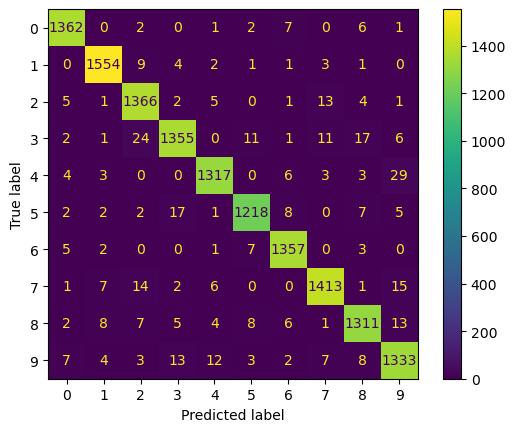

In [14]:
y_val_pred = best_et.predict(X_val_s)

print(classification_report(y_val, y_val_pred, digits=4))
ConfusionMatrixDisplay(confusion_matrix(y_val, y_val_pred)).plot()


## Kodblock 8 – Slutlig testutvärdering


FINAL TEST RESULT:
              precision    recall  f1-score   support

           0     0.9681    0.9899    0.9789      1381
           1     0.9650    0.9797    0.9723      1575
           2     0.9556    0.9385    0.9470      1398
           3     0.9489    0.9356    0.9422      1428
           4     0.9546    0.9392    0.9468      1365
           5     0.9603    0.9382    0.9491      1263
           6     0.9607    0.9782    0.9694      1375
           7     0.9469    0.9527    0.9498      1459
           8     0.9465    0.9333    0.9399      1365
           9     0.9054    0.9224    0.9138      1391

    accuracy                         0.9512     14000
   macro avg     0.9512    0.9508    0.9509     14000
weighted avg     0.9512    0.9512    0.9512     14000



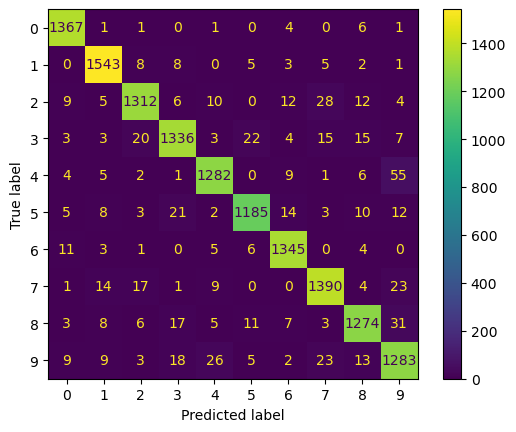

In [15]:
X_train_full_s = np.vstack([X_train_s, X_val_s])
y_train_full = np.hstack([y_train, y_val])

best_params = grid.best_params_.copy()
best_params["max_depth"] = 12
best_params["min_samples_leaf"] = 2

final_et = ExtraTreesClassifier(**best_params, random_state=42, n_jobs=-1)

final_et.fit(X_train_full_s, y_train_full)

y_test_pred = final_et.predict(X_test_s)

print("\nFINAL TEST RESULT:")
print(classification_report(y_test, y_test_pred, digits=4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_test_pred)).plot()


## Kodblock 9 - Sparar ned modellen

In [16]:


joblib.dump(final_et, "mnist_model.pkl")
joblib.dump(scaler, "mnist_scaler.pkl")

['mnist_scaler.pkl']

In [17]:
try:
    joblib.dump(final_et, "mnist_model.pkl")
    joblib.dump(scaler, "mnist_scaler.pkl")
    print("Nedsparat och klart! ✅")
except Exception as e:
    print("Något gick fel vid sparandet:")
    print(e)

Nedsparat och klart! ✅


Extra - Kod för att komma tillrätta med Streamlit-problem

In [18]:
import os, joblib
joblib.dump(final_et, "mnist_model.pkl", compress=3)
print("mnist_model.pkl MB:", os.path.getsize("mnist_model.pkl") / (1024**2))

mnist_model.pkl MB: 66.92852973937988


In [19]:
import sklearn, numpy, joblib
print("sklearn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("joblib:", joblib.__version__)

sklearn: 1.7.2
numpy: 2.3.5
joblib: 1.5.2
